In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [2]:
PROJECT_ROOT = Path.cwd().parent

RESULTS_DIR = PROJECT_ROOT / "results" / "vaac_tiny"

TEST_PREDICTIONS = RESULTS_DIR / "test_predictions.csv"

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)
print("Test predictions:", TEST_PREDICTIONS)

Project root: c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection
Results directory: c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny
Test predictions: c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny\test_predictions.csv


In [3]:
test_prediction_df = pd.read_csv(TEST_PREDICTIONS)

print("Shape:", test_prediction_df.shape)

display(test_prediction_df.head())

Shape: (136, 15)


,recording_id,source_file,signal_id,class,window_id,start_sample,end_sample,label,predicted_label,predicted_class,confidence,prob_Healthy,prob_Ball,prob_Inner Race,prob_Outer Race
0,B007_3_X121,B007_3.mat,X121,Ball,0,0,12000,1,1,Ball,0.995831,0.000002,0.995831,0.004162,0.000006
1,B007_3_X121,B007_3.mat,X121,Ball,1,6000,18000,1,1,Ball,0.994963,0.000002,0.994963,0.005030,0.000005
2,B007_3_X121,B007_3.mat,X121,Ball,2,12000,24000,1,1,Ball,0.994040,0.000002,0.994040,0.005954,0.000004
3,B007_3_X121,B007_3.mat,X121,Ball,3,18000,30000,1,1,Ball,0.996120,0.000002,0.996120,0.003872,0.000006
4,B007_3_X121,B007_3.mat,X121,Ball,4,24000,36000,1,1,Ball,0.995702,0.000002,0.995702,0.004291,0.000006


In [4]:
print(test_prediction_df.columns.tolist())

['recording_id', 'source_file', 'signal_id', 'class', 'window_id', 'start_sample', 'end_sample', 'label', 'predicted_label', 'predicted_class', 'confidence', 'prob_Healthy', 'prob_Ball', 'prob_Inner Race', 'prob_Outer Race']


In [5]:
CLASS_NAMES = [
    "Healthy",
    "Ball",
    "Inner Race",
    "Outer Race"
]

CLASS_TO_INDEX = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}

INDEX_TO_CLASS = {
    index: name
    for index, name in enumerate(CLASS_NAMES)
}

print(CLASS_TO_INDEX)

{'Healthy': 0, 'Ball': 1, 'Inner Race': 2, 'Outer Race': 3}


In [6]:
test_prediction_df = test_prediction_df.sort_values(
    ["signal_id", "window_id"]
).reset_index(drop=True)

display(
    test_prediction_df[
        ["signal_id", "window_id", "class", "predicted_class", "confidence"]
    ].head(20)
)

,signal_id,window_id,class,predicted_class,confidence
0,X100,0,Healthy,Healthy,0.999993
1,X100,1,Healthy,Healthy,0.999991
2,X100,2,Healthy,Healthy,0.999990
3,X100,3,Healthy,Healthy,0.999990
4,X100,4,Healthy,Healthy,0.999990
5,X100,5,Healthy,Healthy,0.999990
6,X100,6,Healthy,Healthy,0.999991
7,X100,7,Healthy,Healthy,0.999991
8,X100,8,Healthy,Healthy,0.999991
9,X100,9,Healthy,Healthy,0.999992


In [7]:
TEMPORAL_WINDOW = 5
def temporal_consensus(predictions, window_size=5):
    """
    Apply majority voting over consecutive predictions.
    """

    predictions = list(predictions)

    if len(predictions) < window_size:
        return predictions[-1]

    recent_predictions = predictions[-window_size:]

    vote_counts = Counter(recent_predictions)

    return vote_counts.most_common(1)[0][0]

In [8]:
example_predictions = [
    "Inner Race",
    "Inner Race",
    "Ball",
    "Inner Race",
    "Outer Race"
]

result = temporal_consensus(
    example_predictions,
    window_size=5
)

print("Predictions:", example_predictions)
print("Consensus:", result)

Predictions: ['Inner Race', 'Inner Race', 'Ball', 'Inner Race', 'Outer Race']
Consensus: Inner Race


In [9]:
consensus_results = []

for signal_id, group in test_prediction_df.groupby("signal_id"):

    group = group.sort_values("window_id").reset_index(drop=True)

    predictions = group["predicted_class"].tolist()

    for i in range(len(predictions)):

        start = max(0, i - TEMPORAL_WINDOW + 1)

        recent_predictions = predictions[start:i + 1]

        consensus_prediction = Counter(
            recent_predictions
        ).most_common(1)[0][0]

        consensus_results.append({
            "signal_id": signal_id,
            "window_id": group.loc[i, "window_id"],
            "actual_class": group.loc[i, "class"],
            "cnn_prediction": predictions[i],
            "temporal_prediction": consensus_prediction,
            "cnn_confidence": group.loc[i, "confidence"]
        })

consensus_df = pd.DataFrame(consensus_results)

display(consensus_df.head(20))

,signal_id,window_id,actual_class,cnn_prediction,temporal_prediction,cnn_confidence
0,X100,0,Healthy,Healthy,Healthy,0.999993
1,X100,1,Healthy,Healthy,Healthy,0.999991
2,X100,2,Healthy,Healthy,Healthy,0.999990
3,X100,3,Healthy,Healthy,Healthy,0.999990
4,X100,4,Healthy,Healthy,Healthy,0.999990
5,X100,5,Healthy,Healthy,Healthy,0.999990
6,X100,6,Healthy,Healthy,Healthy,0.999991
7,X100,7,Healthy,Healthy,Healthy,0.999991
8,X100,8,Healthy,Healthy,Healthy,0.999991
9,X100,9,Healthy,Healthy,Healthy,0.999992


In [10]:
temporal_accuracy = np.mean(
    consensus_df["actual_class"]
    == consensus_df["temporal_prediction"]
)

cnn_accuracy = np.mean(
    consensus_df["actual_class"]
    == consensus_df["cnn_prediction"]
)

print(f"CNN window accuracy: {cnn_accuracy:.4f}")
print(f"Temporal consensus accuracy: {temporal_accuracy:.4f}")

CNN window accuracy: 1.0000
Temporal consensus accuracy: 1.0000


In [11]:
comparison = pd.DataFrame({
    "Method": [
        "VAAC-Tiny CNN",
        "VAAC-Tiny + Temporal Consensus"
    ],
    "Accuracy": [
        cnn_accuracy,
        temporal_accuracy
    ]
})

display(comparison)

,Method,Accuracy
0,VAAC-Tiny CNN,1.0
1,VAAC-Tiny + Temporal Consensus,1.0


In [12]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CONSENSUS_RESULTS = (
    RESULTS_DIR / "temporal_consensus_predictions.csv"
)

consensus_df.to_csv(
    CONSENSUS_RESULTS,
    index=False
)

print("Saved:", CONSENSUS_RESULTS)

Saved: c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny\temporal_consensus_predictions.csv


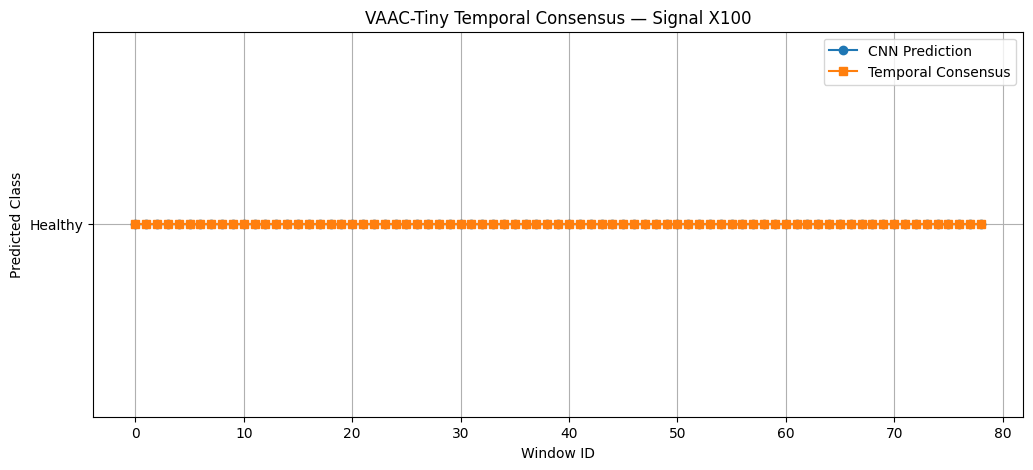

In [13]:
example_signal = consensus_df["signal_id"].iloc[0]

example_df = consensus_df[
    consensus_df["signal_id"] == example_signal
].sort_values("window_id")

plt.figure(figsize=(12, 5))

plt.plot(
    example_df["window_id"],
    example_df["cnn_prediction"],
    marker="o",
    label="CNN Prediction"
)

plt.plot(
    example_df["window_id"],
    example_df["temporal_prediction"],
    marker="s",
    label="Temporal Consensus"
)

plt.xlabel("Window ID")
plt.ylabel("Predicted Class")
plt.title(
    f"VAAC-Tiny Temporal Consensus — Signal {example_signal}"
)

plt.legend()
plt.grid(True)
plt.show()

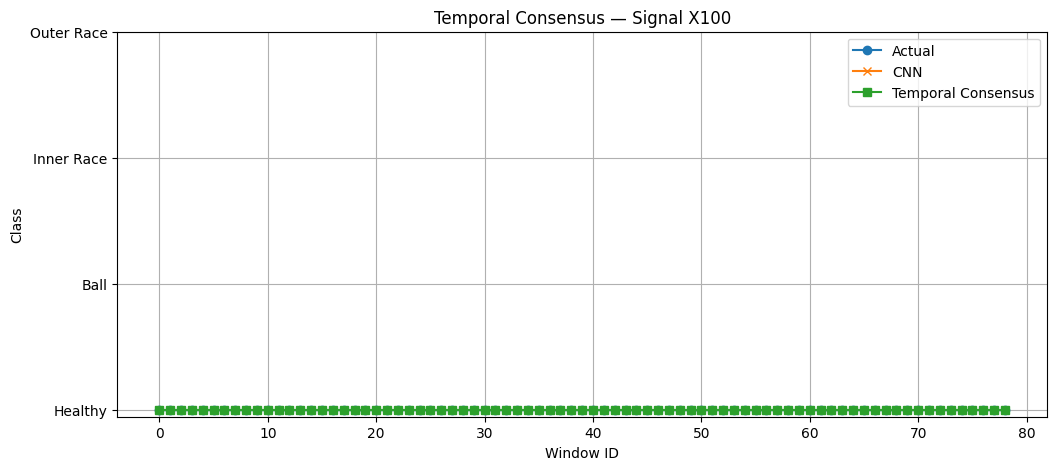

In [14]:
plot_df = example_df.copy()

plot_df["cnn_index"] = plot_df["cnn_prediction"].map(CLASS_TO_INDEX)
plot_df["temporal_index"] = plot_df["temporal_prediction"].map(CLASS_TO_INDEX)
plot_df["actual_index"] = plot_df["actual_class"].map(CLASS_TO_INDEX)

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["window_id"],
    plot_df["actual_index"],
    marker="o",
    label="Actual"
)

plt.plot(
    plot_df["window_id"],
    plot_df["cnn_index"],
    marker="x",
    label="CNN"
)

plt.plot(
    plot_df["window_id"],
    plot_df["temporal_index"],
    marker="s",
    label="Temporal Consensus"
)

plt.yticks(
    range(len(CLASS_NAMES)),
    CLASS_NAMES
)

plt.xlabel("Window ID")
plt.ylabel("Class")
plt.title(
    f"Temporal Consensus — Signal {example_signal}"
)

plt.legend()
plt.grid(True)
plt.show()

In [15]:
FIGURES_DIR = PROJECT_ROOT / "results" / "vaac_tiny" / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

figure_path = (
    FIGURES_DIR /
    f"temporal_consensus_{example_signal}.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

<Figure size 640x480 with 0 Axes>

Saved: c:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\results\vaac_tiny\figures\temporal_consensus_X100.png
